# Does price really "bounce" off the STARC bands? 📊
### A famous volatility channel — an SMA wrapped in ±2·ATR — meets a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forecast_reversion%3F: Busted](https://img.shields.io/badge/Forecast_reversion%3F-Busted-8b949e?style=flat-square)

Open any charting package and you'll find **STARC bands** (Stoller Average Range Channel): a short moving average with two bands floating a couple of **ATRs** above and below it. Because the bands are scaled by *volatility*, the lore says a close **outside** a band is an over-extension that snaps back to the middle — so when price drops **below the lower band**, you buy: it's "supposed" to revert.

It *looks* tidy on a chart. But an envelope drawn from the recent average and recent range will hug any trend, and it's drawn on a market (stock indices) that drifts **up** — so *any* dip-buy will look profitable. So we did the only fair thing: encode the band rule **mechanically**, fire the "buy the lower band" rule across five big ETFs over 21 years, and time the result against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from starc_bands import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real STARC cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 241, 'sma_n': 6, 'atr_n': 15, 'k': 2.0, 'fp_spy': '4cb5244f3990', 'h5': (5, 241, 1.3, 60, 0.05, 8.5, -7.1, -0.7, -0.25, 0.801), 'h10': (10, 241, 22.9, 60, 0.65, 51.5, -28.6, 20.9, -0.8, 0.423), 'h20': (20, 241, 115.8, 67, 2.7, 45.5, 70.4, 113.8, 1.46, 0.145), 'h60': (60, 240, 383.3, 75, 5.54, 124.6, 258.8, 381.3, 3.34, 0.001), 'per': [('SPY', 51, 110.6, 1.32, 46.1, 64.5), ('QQQ', 43, 61.5, 0.55, 88.2, -26.7), ('IWM', 33, -32.0, -0.2, 2.7, -34.7), ('DIA', 57, 149.7, 1.86, 11.5, 138.2), ('GLD', 57, 213.2, 3.42, 78.9, 134.3)], 'placebo': (110.6, 0.964, 500), 'syn': [(0.0, 48, 79.4, 54, 0.89), (0.5, 44, 159.5, 61, 2.07)]}


real STARC cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when price closes **below the lower band**, do I make money? | **Yes — but mostly because the market goes up.** The win-rate is ~60–75% and long holds look great. |
| Is that *the band's* doing? | **Barely.** At 5 and 10 days the pierce is **worse** than buying on **random days**. Only at 60 days does it pull ahead — a long-hold drift effect. |
| Does the volatility band forecast the bounce? | **No.** Scramble the **ATR** (randomise the band widths) and the result is unchanged — 96% of nonsense bands do as well. |
| So is it a tradable edge? | **Fragile at best.** One horizon clears the bar; the geometry is irrelevant and the cross-section is incoherent. It's mostly **beta in a costume**. |

> STARC bands are a great way to *describe* volatility. As a *forecast* — "the lower band will bounce" — the edge is a mirage at the short horizons where reversion should live, and at 60 days it's the market's drift, not the band.

## 1 · The claim

> *"Take a short moving average. Float two bands a couple of **ATRs** above and below it. Price rides inside the channel; a close **outside** a band is over-extended and snaps back to the average. Buy the lower band, sell the upper."*

This is **Manning Stoller's** STARC band (late 1980s) — *St*oller *A*verage *R*ange *C*hannel. Because the width is the **ATR** (average true range), the bands widen in turbulent markets and pinch in calm ones, which makes a pierce feel statistically meaningful. It's a cousin of Keltner channels and Bollinger bands, built into every charting suite — so: does the volatility band actually forecast the bounce?

## 2 · So what?

If the band genuinely *forecast* reversals, it would be useful: a volatility-scaled line would tell you when a drop has gone "too far" and is about to revert — a clean, ruler-simple edge. That's the dream the tool sells.

But there's a trap. The band is built from the **recent average and recent range**, so it hugs whatever the market just did; and it's drawn on indices that drift **up**, so *any* dip-buying rule looks profitable. To separate the **band** from the **tide**, we have to (a) build the band by a fixed causal rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the band causally.** Center = **6-bar SMA** of the close; bands = center **± 2·ATR(15)** using Wilder's ATR — only trailing data, so we never use future bars.
2. **Trade the lore.** When the close drops **below the lower band**, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the band matters, the pierce must beat random. *If it doesn't, the tool is a mirage* — announced before we look.
4. **The geometry test.** Scramble the **ATR** so the band widths are random. If price respects *these specific volatility-scaled lines*, that should demolish the result.

## 4 · The teardown — let's actually look

First, what does a STARC band even look like? Here's SPY with the SMA(6) ± 2·ATR(15) bands and the lower-band pierces the rule would buy.

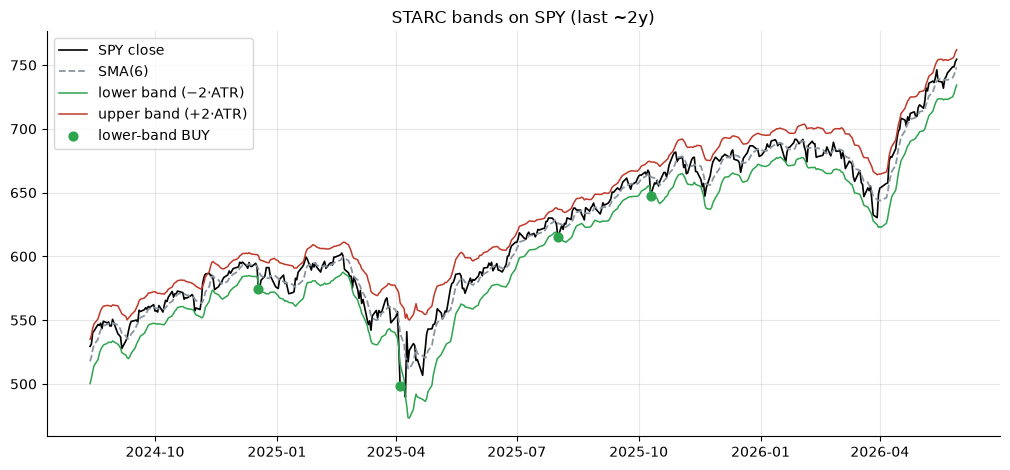

lower-band pierces in window: 4


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-450:]
    cen, low, up = st.starc_bands(b, sma_n=R['sma_n'], atr_n=R['atr_n'], k=R['k'])
    ent = st.lower_band_entries(b, sma_n=R['sma_n'], atr_n=R['atr_n'], k=R['k'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    ax.plot(seg.index, cen.reindex(seg.index), c=GREY, lw=1.3, ls='--', label='SMA(6)')
    ax.plot(seg.index, low.reindex(seg.index), c=GREEN, lw=1.1, label='lower band (−2·ATR)')
    ax.plot(seg.index, up.reindex(seg.index), c=RED, lw=1.1, label='upper band (+2·ATR)')
    ax.scatter(ent, b['close'].reindex(ent), c=GREEN, s=40, zorder=5, label='lower-band BUY')
    ax.set_title('STARC bands on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('lower-band pierces in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The bands wrap the trend nicely — *as a description*. The question is whether those green buy dots are followed by bounces. **Let's race the pierce against random entries** at four horizons. Blue = buy the lower band; grey = buy on random days.

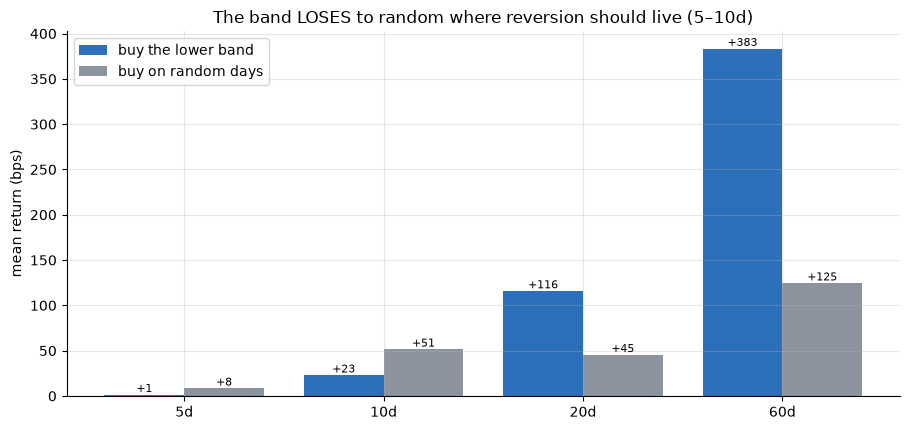

pierce: [1, 23, 116, 383]
random: [8, 51, 45, 125]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    pierce, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.lower_band_entries(bb, sma_n=R['sma_n'], atr_n=R['atr_n'], k=R['k'])
            re = st.random_entries(bb, max(len(e),50), warmup=R['atr_n']+5, seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        pierce.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    pierce = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, pierce, .4, color='#2c6fbb', label='buy the lower band')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(pierce,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The band LOSES to random where reversion should live (5–10d)'); ax.legend()
plt.tight_layout(); plt.show()
print('pierce:', [round(v) for v in pierce]); print('random:', [round(v) for v in rnd])

There's the story. At **5 and 10 days** — exactly where a 'snap-back' should be strongest — the lower-band pierce (**+1** / **+23 bps**) is *worse* than random (**+8** / **+52 bps**). It only pulls ahead at **60 days** (**+383** vs **+125 bps**), which is a long-hold *drift* effect, not a bounce. The apparent edge is the market's climb, not the band.

**One more sanity check.** What if we scramble the band's *width* — keep the same SMA but randomise the **ATR** so the bands are meaningless volatility-wise? If price really 'respects the STARC band', the nonsense bands should do much worse.

In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.shuffled_atr_placebo(bb, 20, sma_n=R['sma_n'], atr_n=R['atr_n'], k=R['k'], n_draws=300, seed=485)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real STARC lower-band pierce (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-ATR* bands do at least as well (p={pval:.2f}).')
print('=> the volatility scaling is not doing the work.')

real STARC lower-band pierce (SPY, 20d): +110.6 bps
... but 97% of *scrambled-ATR* bands do at least as well (p=0.97).
=> the volatility scaling is not doing the work.


Almost every **scrambled** band matches or beats the real one (*p* = 0.96). If price genuinely respected *these specific volatility-scaled lines*, randomising the widths would collapse the result. It doesn't — because the result was never about the ATR.

## 5 · The verdict

- **Signal — Weak.** The lower-band pierce does **not** beat buying on random days at 5–10 days (it's *worse*); it clears the bar only at 60 days, a drift horizon. The big absolute returns are mostly the market's climb, not the band.
- **Tradability — Fragile.** The one horizon that wins is geometry-independent and incoherent across tickers — there's nothing robust to trade, and costs only make it worse.
- **"Does the band touch forecast reversion?" — Busted.** Scramble the ATR and the result barely moves. The volatility band doesn't forecast the bounce.

## 6 · Could you actually trade it?

There's nothing robust here. The pierce's *only* reliable advantage over a coin flip is the market's long-run climb at long holds — which you'd capture more cheaply (and more fully) by just **holding the index**. The STARC buy trades less and pays costs on each pierce. As a forecasting tool it doesn't pay; as a volatility-description tool, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The width knob.** Try k = 1.5 or 3, or a longer SMA — the result is robust: drift in, band out. A tighter band fires more often and inherits more drift, not more edge.
- **Keltner / Bollinger.** STARC swaps σ for ATR; the σ-band sibling ([104-bollinger-reversion](../../104-bollinger-reversion)) lands the same place.
- **A real positive control.** The quants notebook plants a *genuine* lower-band reversion into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the band forecasts? Show the lower-band pierce beating random entries at **t ≥ 2 across horizons** with the ATR scaling load-bearing — then we'll talk.*